1. Explain the Architectures of Neural Networks

A Neural Network is a machine learning model inspired by the human brain. It consists of interconnected nodes called neurons that process information and learn patterns from data. Neural networks are mainly used in Deep Learning for tasks such as image recognition, speech recognition, NLP, and prediction systems.

Basic Architecture of Neural Networks

A neural network generally contains three main layers:

1. Input Layer
The first layer of the network.
Receives input data from the user or dataset.
Each neuron represents one feature of the data.
Example:

If a dataset has:

Age
Salary
Experience

Then the input layer will have 3 neurons.

2. Hidden Layer
Performs calculations and feature extraction.
Uses weights, biases, and activation functions.
A network can have one or many hidden layers.
Functions of Hidden Layers:
Detect patterns
Learn relationships
Improve prediction accuracy
3. Output Layer
Produces the final prediction or result.
Example:
Binary classification → 1 neuron
Multi-class classification → multiple neurons
Structure of Neural Network
Input Layer → Hidden Layer(s) → Output Layer
Important Components of Neural Networks
A. Neurons

A neuron receives input, performs calculations, and gives output.

B. Weights
Weights determine the importance of input values.
Neural networks learn by adjusting weights.
C. Bias
Helps the model improve flexibility and accuracy.
D. Activation Functions



Presentation: Differences between CNNs, RNNs and Transformers
Introduction



1. CNN (Convolutional Neural Network)

Definition

CNN is a deep learning architecture mainly used for image processing and computer vision tasks.

Architecture of CNN

Input Image → Convolution Layer → Pooling Layer → Fully Connected Layer → Output

Main Components

Convolution Layer
Pooling Layer
Activation Function
Fully Connected Layer

Features

Detects edges, shapes, and patterns
Works efficiently with image data
Reduces image dimensions using pooling

Advantages

High accuracy in image classification
Automatic feature extraction
Less manual preprocessing

Disadvantages

Not suitable for sequential data
Requires large datasets

Applications

Face recognition
Object detection
Medical image analysis
Self-driving cars

2. RNN (Recurrent Neural Network)

Definition

RNN is a neural network architecture designed for sequential and time-series data.

Architecture of RNN
Input → Hidden State Loop → Output

Features

Remembers previous information
Processes data step-by-step
Suitable for sequential patterns

Advantages

Handles sequential data effectively
Useful for speech and text processing

Disadvantages

Slow training process
Suffers from vanishing gradient problem
Difficulty handling long-term dependencies

Applications

Speech recognition
Language translation
Text prediction
Sentiment analysis

3. Transformers

Definition

Transformers are advanced deep learning architectures that use self-attention mechanisms to process sequential data efficiently.

Architecture of Transformers
Input Embedding → Self-Attention → Feed Forward Network → Output

Main Components

Encoder
Decoder
Self-Attention Mechanism
Positional Encoding

Features

Processes all words simultaneously
Captures long-range dependencies
Faster training compared to RNN

Advantages

High accuracy in NLP tasks
Parallel processing
Excellent performance for large datasets

Disadvantages

Requires high computational power
Needs large memory and GPUs

Applications

Chatbots
Machine translation
Text summarization
AI assistants

Task 1: Predicting Customer Churn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [ ]:
df = pd.read_csv("C:/Users/prince/Downloads/archive (17)/BankChurners.csv")

print(df.head())

   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ...       12691.0                  777          11914.0   
1       

In [ ]:

print(df.shape)

print(df.info())

print(df.isnull().sum())

(10127, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                               

In [ ]:
df.drop(['CLIENTNUM'], axis=1, inplace=True)

In [ ]:
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer':0,
    'Attrited Customer':1
})

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Attrition_Flag', axis=1)

y = df['Attrition_Flag']

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

model.add(Dense(64,
                activation='relu',
                input_dim=X_train.shape[1]))

model.add(Dense(32,
                activation='relu'))

model.add(Dense(1,
                activation='sigmoid'))

c:\Users\prince\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9614 - loss: 0.1167 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 8.5406e-04
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 5.3643e-04 - val_accuracy: 1.0000 - val_loss: 3.5341e-04
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.5406e-04 - val_accuracy: 1.0000 - val_loss: 1.9076e-04
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.4667e-04 - val_accuracy: 1.0000 - val_loss: 1.1804e-04
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 9.4631e-05 - val_accuracy: 1.0000 - val_loss: 7.9123e-05
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.5582e-05 - val_accuracy: 1.0000 - val_loss: 5.6451e-05
Epoch 8/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accura

In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1699    0]
 [   0  327]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1699
           1       1.00      1.00      1.00       327

    accuracy                           1.00      2026
   macro avg       1.00      1.00      1.00      2026
weighted avg       1.00      1.00      1.00      2026



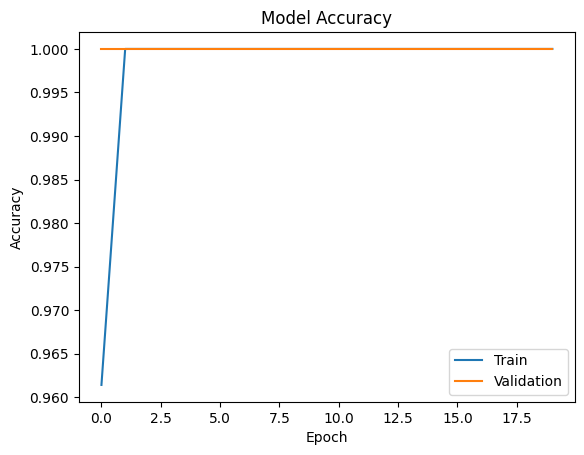

In [ ]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

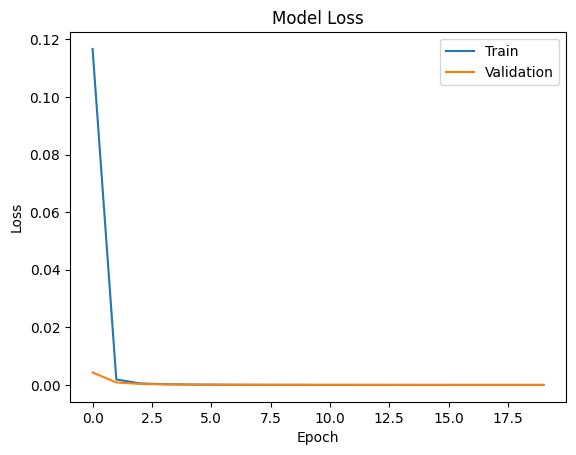

In [ ]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.ylabel('Loss')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

Task 2: Digit Recognizer

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
from mlxtend.data import loadlocal_mnist

# Load training data
X_train, y_train = loadlocal_mnist(
    images_path='D:/asignment/module8/archive (18)/train-images.idx3-ubyte',  # Changed - to .
    labels_path='D:/asignment/module8/archive (18)/train-labels.idx1-ubyte'
)

# Load testing data
X_test, y_test = loadlocal_mnist(
    images_path='D:/asignment/module8/archive (18)/t10k-images.idx3-ubyte',
    labels_path='D:/asignment/module8/archive (18)/t10k-labels.idx1-ubyte'
)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [ ]:
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


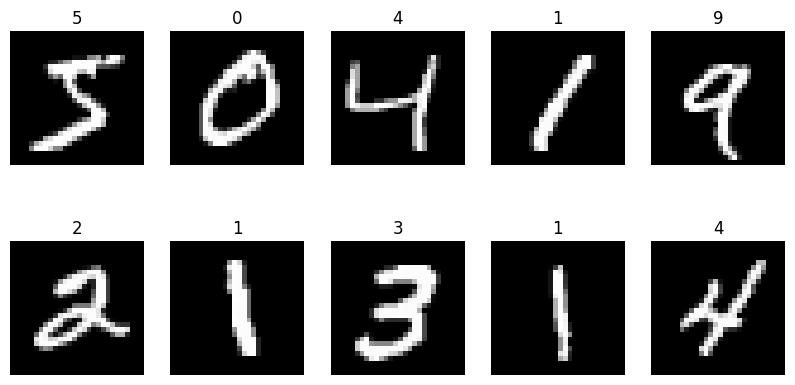

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(np.argmax(y_train[i]))
    plt.axis('off')

plt.show()

In [ ]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

c:\Users\prince\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9143 - loss: 0.2771 - val_accuracy: 0.9811 - val_loss: 0.0638
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9710 - loss: 0.0958 - val_accuracy: 0.9849 - val_loss: 0.0501
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9789 - loss: 0.0689 - val_accuracy: 0.9859 - val_loss: 0.0468
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9822 - loss: 0.0590 - val_accuracy: 0.9899 - val_loss: 0.0373
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9846 - loss: 0.0502 - val_accuracy: 0.9900 - val_loss: 0.0356


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9906 - loss: 0.0276
Loss: 0.02759806253015995
Accuracy: 0.9905999898910522


In [ ]:
predictions = model.predict(X_test)

print("Predicted Digit:",
      np.argmax(predictions[0]))

print("Actual Digit:",
      np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicted Digit: 7
Actual Digit: 7


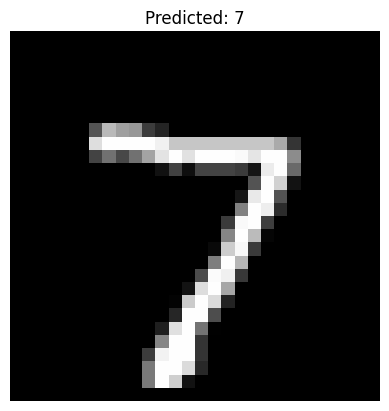

In [ ]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted: " + str(np.argmax(predictions[0])))
plt.axis('off')
plt.show()

Task 3: Sentiment Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = pd.read_csv("C:/Users/prince/Downloads/archive (19)/imdb-movies-dataset.csv")

print(df.head())
print(df.columns)

                                              Poster  \
0  https://m.media-amazon.com/images/M/MV5BYWRkZj...   
1  https://m.media-amazon.com/images/M/MV5BZGI4NT...   
2  https://m.media-amazon.com/images/M/MV5BZjIyOT...   
3  https://m.media-amazon.com/images/M/MV5BMjA5Zj...   
4  https://m.media-amazon.com/images/M/MV5BNTk1MT...   

                               Title    Year Certificate  Duration (min)  \
0                    The Idea of You  2023.0           R           115.0   
1  Kingdom of the Planet of the Apes  2023.0       PG-13           145.0   
2                          Unfrosted  2023.0       PG-13            97.0   
3                       The Fall Guy  2023.0       PG-13           126.0   
4                        Challengers  2023.0           R           131.0   

                        Genre  Rating  Metascore           Director  \
0      Comedy, Drama, Romance     6.4       67.0  Michael Showalter   
1   Action, Adventure, Sci-Fi     7.3       66.0           Wes B

In [ ]:
print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Poster          10000 non-null  object 
 1   Title           10000 non-null  object 
 2   Year            9850 non-null   float64
 3   Certificate     7370 non-null   object 
 4   Duration (min)  9664 non-null   float64
 5   Genre           9993 non-null   object 
 6   Rating          9596 non-null   float64
 7   Metascore       7555 non-null   float64
 8   Director        9995 non-null   object 
 9   Cast            9961 non-null   object 
 10  Votes           9596 non-null   object 
 11  Description     10000 non-null  object 
 12  Review Count    9999 non-null   object 
 13  Review Title    9483 non-null   object 
 14  Review          9484 non-null   object 
dtypes: float64(4), object(11)
memory usage: 1.1+ MB
None
Poster               0
Title                0
Year               150


In [ ]:
# 1. Drop rows that have missing values in 'Review' or 'Rating'
df_clean = df.dropna(subset=['Review', 'Rating']).copy()

# 2. Extract reviews using the correct capitalized column name
reviews = df_clean['Review']

# 3. Derive 'sentiment' based on the 'Rating' column (e.g., positive if >= 7.0, otherwise negative)
df_clean['sentiment'] = df_clean['Rating'].apply(lambda x: 'positive' if x >= 7.0 else 'negative')
sentiments = df_clean['sentiment']


In [ ]:
encoder = LabelEncoder()

sentiments = encoder.fit_transform(sentiments)

print(sentiments[:10])

[0 1 0 1 1 0 1 0 1 1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    reviews,
    sentiments,
    test_size=0.2,
    random_state=42
)

In [ ]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length
)

print(X_train_pad.shape)

(7585, 200)


In [ ]:
rnn_model = Sequential()

rnn_model.add(
    Embedding(input_dim=5000,
              output_dim=128,
              input_length=max_length)
)

rnn_model.add(
    SimpleRNN(64)
)

rnn_model.add(Dropout(0.5))

rnn_model.add(
    Dense(1, activation='sigmoid')
)

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

c:\Users\prince\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6201 - loss: 0.6648 - val_accuracy: 0.6790 - val_loss: 0.6379
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7195 - loss: 0.5607 - val_accuracy: 0.6051 - val_loss: 0.6700
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8868 - loss: 0.3161 - val_accuracy: 0.5860 - val_loss: 0.7768
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9801 - loss: 0.0960 - val_accuracy: 0.5880 - val_loss: 0.9696
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9980 - loss: 0.0248 - val_accuracy: 0.6104 - val_loss: 1.0730


In [ ]:
rnn_loss, rnn_acc = rnn_model.evaluate(
    X_test_pad,
    y_test
)

print("RNN Accuracy:", rnn_acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6131 - loss: 1.0648
RNN Accuracy: 0.6130732893943787


In [ ]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=5000,
              output_dim=128,
              input_length=max_length)
)

lstm_model.add(
    LSTM(64)
)

lstm_model.add(Dropout(0.5))

lstm_model.add(
    Dense(1, activation='sigmoid')
)

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.6610 - loss: 0.6355 - val_accuracy: 0.7053 - val_loss: 0.5751
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.7520 - loss: 0.5225 - val_accuracy: 0.6961 - val_loss: 0.5725
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.8192 - loss: 0.4197 - val_accuracy: 0.7080 - val_loss: 0.6580
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.8644 - loss: 0.3362 - val_accuracy: 0.6974 - val_loss: 0.6822
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.9018 - loss: 0.2625 - val_accuracy: 0.6625 - val_loss: 0.7176


In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_pad,
    y_test
)

print("LSTM Accuracy:", lstm_acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6484 - loss: 0.7667
LSTM Accuracy: 0.6483922004699707


In [ ]:
gru_model = Sequential()

gru_model.add(
    Embedding(input_dim=5000,
              output_dim=128,
              input_length=max_length)
)

gru_model.add(
    GRU(64)
)

gru_model.add(Dropout(0.5))

gru_model.add(
    Dense(1, activation='sigmoid')
)

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - accuracy: 0.6561 - loss: 0.6430 - val_accuracy: 0.6842 - val_loss: 0.6112
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.7142 - loss: 0.5566 - val_accuracy: 0.6902 - val_loss: 0.6017
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.7980 - loss: 0.4449 - val_accuracy: 0.6500 - val_loss: 0.6442
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.8466 - loss: 0.3531 - val_accuracy: 0.6724 - val_loss: 0.7404
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.8942 - loss: 0.2726 - val_accuracy: 0.6513 - val_loss: 0.8485


In [ ]:
gru_loss, gru_acc = gru_model.evaluate(
    X_test_pad,
    y_test
)

print("GRU Accuracy:", gru_acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6526 - loss: 0.8950
GRU Accuracy: 0.6526094079017639


In [ ]:
print("RNN Accuracy :", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy :", gru_acc)

RNN Accuracy : 0.6130732893943787
LSTM Accuracy: 0.6483922004699707
GRU Accuracy : 0.6526094079017639


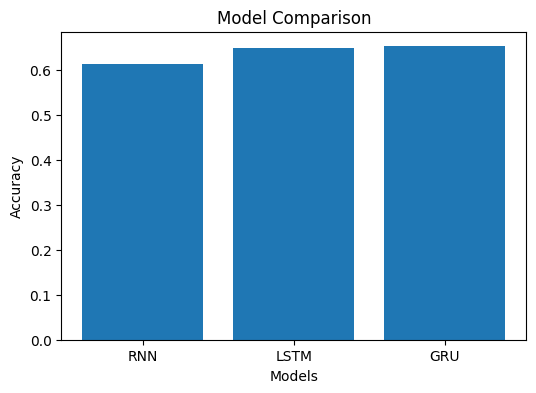

In [ ]:
models = ['RNN', 'LSTM', 'GRU']

accuracies = [
    rnn_acc,
    lstm_acc,
    gru_acc
]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

In [ ]:
sample_review = ["This movie was amazing and fantastic"]

sample_seq = tokenizer.texts_to_sequences(sample_review)

sample_pad = pad_sequences(
    sample_seq,
    maxlen=max_length
)

prediction = lstm_model.predict(sample_pad)

if prediction > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
Positive Review


Task 4 : Build a text classifier model for emotion detection in text. [NLP]

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
df = pd.read_csv("C:/Users/prince/Downloads/archive (20)/archive/combined_emotion.csv")

In [7]:
print(df.head())
print(df.columns)
print(df.shape)

                                            sentence emotion
0      i just feel really helpless and heavy hearted    fear
1  ive enjoyed being able to slouch about relax a...     sad
2  i gave up my internship with the dmrg and am f...    fear
3                         i dont know i feel so lost     sad
4  i am a kindergarten teacher and i am thoroughl...    fear
Index(['sentence', 'emotion'], dtype='str')
(422746, 2)


In [8]:

print(df.isnull().sum())
print(df['emotion'].value_counts())

sentence    0
emotion     0
dtype: int64
emotion
joy        143067
sad        121187
anger       59317
fear        49649
love        34554
suprise     14972
Name: count, dtype: int64


In [9]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prince\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prince\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # tokenize
    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    # lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [11]:
df['clean_text'] = df['sentence'].apply(clean_text)


In [12]:
tfidf = TfidfVectorizer(max_features=5000)

# Keep X as a sparse matrix (do not call .toarray())
X = tfidf.fit_transform(df['clean_text'])

y = df['emotion']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LogisticRegression()

model.fit(X_train, y_train)

c:\Users\prince\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9017031342400946


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.91      0.91      0.91     11810
        fear       0.86      0.86      0.86      9952
         joy       0.92      0.94      0.93     28781
        love       0.80      0.77      0.79      6929
         sad       0.94      0.94      0.94     24036
     suprise       0.79      0.71      0.75      3042

    accuracy                           0.90     84550
   macro avg       0.87      0.85      0.86     84550
weighted avg       0.90      0.90      0.90     84550



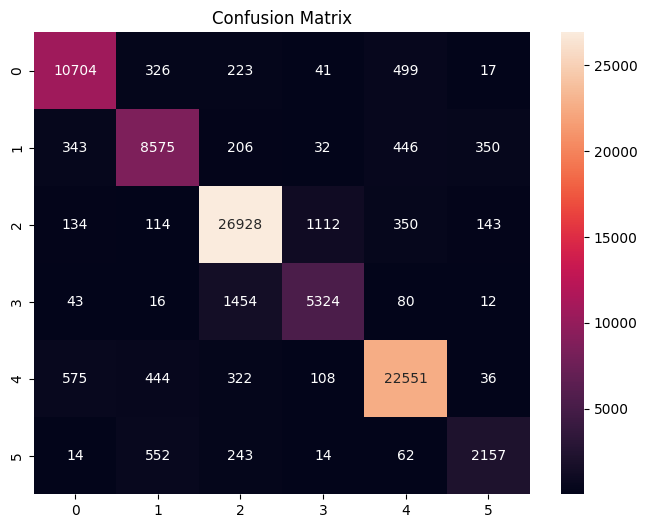

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [20]:
sample = ["I am feeling very happy today"]

sample_clean = [clean_text(text) for text in sample]

sample_vector = tfidf.transform(sample_clean)

prediction = model.predict(sample_vector)

print("Predicted Emotion:", prediction[0])

Predicted Emotion: joy


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [22]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])

X = pad_sequences(X, maxlen=100)

In [23]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df['emotion'])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))

model.add(LSTM(64))

model.add(Dense(64, activation='relu'))

model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

c:\Users\prince\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=1,
    batch_size=32,
    validation_data=(X_test, y_test)
)

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)